In [12]:
!pip install -q ultralytics huggingface_hub pillow
"""
Détection de cases cochées sur des formulaires avec un modèle pré-entraîné
============================================================================

COMMENT UTILISER CE SCRIPT DANS GOOGLE COLAB :

1. !pip install -q ultralytics huggingface_hub pillow          (1ère cellule)

2. Upload les 3 images de formulaires
   (formulaire_type_pack.png, formulaire_sous_branche.png,
    formulaire_type_quittance.png) dans Colab

3. Copie-colle ce script dans une cellule et exécute-le

Ce modèle est déjà entraîné (pas besoin de l'entraîner toi-même) :
il sait détecter des cases "checked"/"unchecked" sur n'importe quelle
image de formulaire. On ajoute ensuite une étape simple : associer
la position de chaque case au bon label métier (ex: 2ème case du haut
= "SECURITE +"), car nos formulaires ont toujours la même structure.
"""

from huggingface_hub import HfApi, hf_hub_download

# ---------------------------------------------------------------
# ÉTAPE 1 : Télécharger le modèle pré-entraîné
# ---------------------------------------------------------------
api = HfApi()
repo_id = "linhdo/checkbox-detector"

files = api.list_repo_files(repo_id=repo_id, repo_type="space")
pt_files = [f for f in files if f.endswith(".pt")]
print("Fichiers de poids trouvés :", pt_files)

assert len(pt_files) > 0, "Aucun .pt trouvé — le repo a peut-être changé de structure."

# On évite les poids de classification pure, on veut la DÉTECTION
detect_weights = [f for f in pt_files if "classif" not in f.lower()]
weights_path = hf_hub_download(
    repo_id=repo_id,
    repo_type="space",
    filename=detect_weights[0] if detect_weights else pt_files[0],
)
print("Poids téléchargés :", weights_path)

# ---------------------------------------------------------------
# ÉTAPE 2 : Compatibilité avec les anciens checkpoints ultralytics
# ---------------------------------------------------------------
import ultralytics.utils as _u
if not hasattr(_u, "yaml_load"):
    try:
        from ultralytics.utils.yaml import yaml_load as _yaml_load
    except ImportError:
        import yaml
        def _yaml_load(file, append_filename=False):
            with open(file, errors="ignore", encoding="utf-8") as f:
                data = yaml.safe_load(f) or {}
            if append_filename:
                data["yaml_file"] = str(file)
            return data
    _u.yaml_load = _yaml_load

from ultralytics import YOLO
model = YOLO(weights_path)
print("Task :", model.task)
print("Classes du modèle :", model.names)

# ---------------------------------------------------------------
# ÉTAPE 3 : Définir nos formulaires + le mapping position -> label
# (l'ordre correspond à l'ordre des cases DE HAUT EN BAS dans l'image)
# ---------------------------------------------------------------
FORMULAIRES = {
    "formulaire_type_pack.png": ["Inconnu", "SECURITE", "SECURITE +",
                                   "SERENITE", "SUPER SECURITE"],
    "formulaire_sous_branche.png": ["Individuel a la carte", "Trik Slema",
                                      "Vehicule etranger", "Flottes"],
    "formulaire_type_quittance.png": ["C - Comptant", "R - Reglement",
                                        "T - Terme"],
}

# ---------------------------------------------------------------
# ÉTAPE 4 : Détecter les cases cochées et retrouver le bon label
# ---------------------------------------------------------------
resultats_finaux = {}

for image_path, labels in FORMULAIRES.items():
    results = model.predict(image_path, conf=0.25, iou=0.45, verbose=False)

    cases_detectees = []
    for r in results:
        for box in r.boxes:
            cls_name = model.names[int(box.cls)]
            conf = float(box.conf)
            y_center = float(box.xywh[0][1])  # position verticale
            cases_detectees.append((y_center, cls_name, conf))

    # Trie les cases de haut en bas pour les associer aux labels dans l'ordre
    cases_detectees.sort(key=lambda x: x[0])

    print(f"\n--- {image_path} ---")
    valeur_trouvee = None
    for i, (y, cls_name, conf) in enumerate(cases_detectees):
        label_associe = labels[i] if i < len(labels) else "?"
        est_cochee = "checked" in cls_name.lower() and "un" not in cls_name.lower()
        print(f"  Case {i+1} ({label_associe}) -> {cls_name} (conf: {conf:.2f})"
              f"{'  <<< COCHÉE' if est_cochee else ''}")
        if est_cochee:
            valeur_trouvee = label_associe

    resultats_finaux[image_path] = valeur_trouvee

# ---------------------------------------------------------------
# ÉTAPE 5 : Résumé final, prêt à être injecté dans tes tables Dim
# ---------------------------------------------------------------
print("\n=== RÉSUMÉ (valeurs à écrire dans les tables Dim) ===")
for image_path, valeur in resultats_finaux.items():
    print(f"{image_path} -> {valeur}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 4.8 MB/s eta 0:00:00
Fichiers de poids trouvés : ['models/classifier-model.pt', 'models/detector-model.pt']


models/detector-model.pt: reconstructing file:   0%|          |  0.00B / 87.6MB            

models/detector-model.pt: downloading bytes:           |  0.00B            

Poids téléchargés : /root/.cache/huggingface/hub/spaces--linhdo--checkbox-detector/snapshots/0148d3cac2968bddad39b498f870c8fd2c0f6850/models/detector-model.pt
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Task : detect
Classes du modèle : {0: 'unchecked', 1: 'checked', 2: 'mst'}

--- formulaire_type_pack.png ---
  Case 1 (Inconnu) -> unchecked (conf: 0.92)
  Case 2 (SECURITE) -> unchecked (conf: 0.91)
  Case 3 (SECURITE +) -> checked (conf: 0.87)  <<< COCHÉE
  Case 4 (SERENITE) -> unchecked (conf: 0.92)
  Case 5 (SUPER SECURITE) -> unchecked (conf: 0.91)

--- formulaire_sous_branche.png ---
  Case 1 (Individuel a la carte) -> unchecked (conf: 0.93)
  Case 2 (Trik Slema) -> checked (conf: 0.88)  <<< COCHÉE
  Case 3 (Vehicule et

In [14]:
!unzip -o scans_clients.zip

Archive:  scans_clients.zip
   creating: scans_clients/
  inflating: scans_clients/client_001.png  
  inflating: scans_clients/client_005.png  
  inflating: scans_clients/client_002.png  
  inflating: scans_clients/client_008.png  
  inflating: scans_clients/client_007.png  
  inflating: scans_clients/client_004.png  
  inflating: scans_clients/client_003.png  
  inflating: scans_clients/client_006.png  
  inflating: generer_exemples_clients.py  


Modèle chargé. Classes : {0: 'unchecked', 1: 'checked', 2: 'mst'}

8 formulaire(s) trouvé(s) dans 'scans_clients/'
  [OK] client_001 -> {'type_quittance': 'C - Comptant', 'sous_branche': 'Trik Slema', 'type_pack': 'SECURITE +'}
  [OK] client_002 -> {'type_quittance': 'C - Comptant', 'sous_branche': 'Trik Slema', 'type_pack': 'SECURITE +'}
  [OK] client_003 -> {'type_quittance': 'T - Terme', 'sous_branche': 'Flottes', 'type_pack': 'SUPER SECURITE'}
  [OK] client_004 -> {'type_quittance': 'R - Reglement', 'sous_branche': 'Individuel a la carte', 'type_pack': 'SECURITE'}
  [OK] client_005 -> {'type_quittance': 'C - Comptant', 'sous_branche': 'Trik Slema', 'type_pack': 'SECURITE +'}
  [OK] client_006 -> {'type_quittance': 'T - Terme', 'sous_branche': 'Trik Slema', 'type_pack': 'SECURITE +'}
  [OK] client_007 -> {'type_quittance': 'C - Comptant', 'sous_branche': 'Flottes', 'type_pack': 'SERENITE'}
  [OK] client_008 -> {'type_quittance': 'T - Terme', 'sous_branche': 'Trik Slema', 'type_pack'

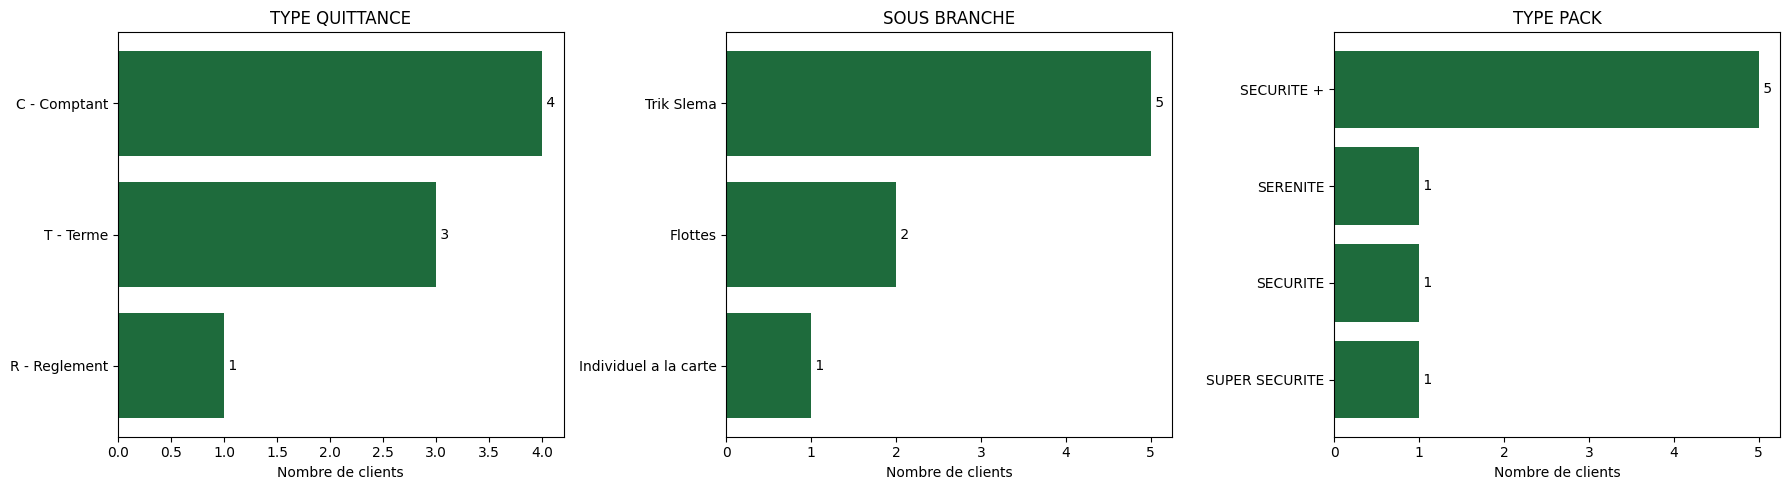


Graphique sauvegardé -> preferences_clients.png

=== COMBINAISON SOUS-BRANCHE x PACK LA PLUS FRÉQUENTE ===
sous_branche           type_pack     
Trik Slema             SECURITE +        5
Flottes                SERENITE          1
                       SUPER SECURITE    1
Individuel a la carte  SECURITE          1
dtype: int64


In [15]:
!pip install -q ultralytics huggingface_hub pillow pandas matplotlib
"""
Analyse des préférences clients à partir de formulaires scannés/photographiés
==============================================================================

OBJECTIF
--------
Avant : le script lisait UN SEUL formulaire (3 images séparées) et affichait
juste la case cochée.

Maintenant : on veut traiter PLUSIEURS formulaires (un par client), extraire
automatiquement les 3 choix de chaque client, puis calculer des statistiques
du type "quel pack est le plus choisi par les clients ?", "quelle
sous-branche est la plus demandée ?", etc.

COMMENT UTILISER CE SCRIPT DANS GOOGLE COLAB :

1. !pip install -q ultralytics huggingface_hub pillow pandas matplotlib

2. Crée un dossier "scans_clients/" et mets dedans une photo/scan par
   client (le formulaire combiné, rempli et coché à la main).
   Nomme les fichiers librement, ex : client_001.jpg, client_002.jpg, ...
   (ou avec un vrai nom/numéro de police si tu préfères)

3. Copie-colle ce script dans une cellule et exécute-le

4. Résultats produits :
   - resultats_clients.csv   -> 1 ligne par client avec ses 3 choix
   - Un résumé en % pour chaque catégorie
   - Des graphiques à barres des préférences les plus fréquentes
"""

import glob
import os
from collections import OrderedDict

import pandas as pd
import matplotlib.pyplot as plt
from huggingface_hub import HfApi, hf_hub_download

# ---------------------------------------------------------------
# ÉTAPE 1 : Télécharger le modèle pré-entraîné (inchangé)
# ---------------------------------------------------------------
api = HfApi()
repo_id = "linhdo/checkbox-detector"

files = api.list_repo_files(repo_id=repo_id, repo_type="space")
pt_files = [f for f in files if f.endswith(".pt")]
detect_weights = [f for f in pt_files if "classif" not in f.lower()]
weights_path = hf_hub_download(
    repo_id=repo_id,
    repo_type="space",
    filename=detect_weights[0] if detect_weights else pt_files[0],
)

import ultralytics.utils as _u
if not hasattr(_u, "yaml_load"):
    try:
        from ultralytics.utils.yaml import yaml_load as _yaml_load
    except ImportError:
        import yaml
        def _yaml_load(file, append_filename=False):
            with open(file, errors="ignore", encoding="utf-8") as f:
                data = yaml.safe_load(f) or {}
            if append_filename:
                data["yaml_file"] = str(file)
            return data
    _u.yaml_load = _yaml_load

from ultralytics import YOLO
model = YOLO(weights_path)
print("Modèle chargé. Classes :", model.names)

# ---------------------------------------------------------------
# ÉTAPE 2 : Structure du formulaire combiné (doit matcher le PDF envoyé
# aux clients : TYPE_QUITTANCE (3) -> SOUS_BRANCHE (4) -> TYPE_PACK (5)
# ---------------------------------------------------------------
SECTIONS = OrderedDict([
    ("type_quittance", ["C - Comptant", "R - Reglement", "T - Terme"]),
    ("sous_branche", ["Individuel a la carte", "Trik Slema",
                       "Vehicule etranger", "Flottes"]),
    ("type_pack", ["Inconnu", "SECURITE", "SECURITE +",
                   "SERENITE", "SUPER SECURITE"]),
])
TAILLES_SECTIONS = [len(v) for v in SECTIONS.values()]  # [3, 4, 5]
NB_CASES_ATTENDU = sum(TAILLES_SECTIONS)                 # 12

DOSSIER_SCANS = "scans_clients"   # <-- change si besoin
EXTENSIONS = ("*.png", "*.jpg", "*.jpeg")

# ---------------------------------------------------------------
# ÉTAPE 3 : Fonction qui lit UN formulaire client et renvoie ses choix
# ---------------------------------------------------------------
def lire_formulaire(image_path, x_tolerance=25):
    results = model.predict(image_path, conf=0.25, iou=0.45, verbose=False)

    cases = []
    for r in results:
        for box in r.boxes:
            cls_name = model.names[int(box.cls)]
            if cls_name not in ("checked", "unchecked"):
                continue  # on ignore la classe "mst" et le bruit
            x_center = float(box.xywh[0][0])
            y_center = float(box.xywh[0][1])
            conf = float(box.conf)
            cases.append((x_center, y_center, cls_name, conf))

    if not cases:
        return None, "Aucune case détectée"

    # Les vraies cases à cocher du formulaire sont toutes alignées sur
    # la même colonne (même x). On garde la colonne la plus peuplée pour
    # éliminer le bruit (lignes de signature, cadres, etc.)
    xs = sorted(c[0] for c in cases)
    x_reference = xs[len(xs) // 2]  # médiane
    cases = [c for c in cases if abs(c[0] - x_reference) <= x_tolerance]

    cases.sort(key=lambda c: c[1])  # tri haut -> bas

    if len(cases) != NB_CASES_ATTENDU:
        return None, f"{len(cases)} cases détectées au lieu de {NB_CASES_ATTENDU} (photo à revérifier)"

    # Découpe en groupes selon la taille de chaque section
    resultat = {}
    idx = 0
    for (nom_section, labels), taille in zip(SECTIONS.items(), TAILLES_SECTIONS):
        groupe = cases[idx: idx + taille]
        idx += taille

        coches = [i for i, c in enumerate(groupe) if c[2] == "checked"]
        if len(coches) == 1:
            resultat[nom_section] = labels[coches[0]]
        elif len(coches) == 0:
            resultat[nom_section] = None  # section non remplie
        else:
            resultat[nom_section] = "AMBIGU (plusieurs cases cochées)"

    return resultat, None


# ---------------------------------------------------------------
# ÉTAPE 4 : Traiter tous les scans du dossier
# ---------------------------------------------------------------
chemins = []
for ext in EXTENSIONS:
    chemins.extend(glob.glob(os.path.join(DOSSIER_SCANS, ext)))

print(f"\n{len(chemins)} formulaire(s) trouvé(s) dans '{DOSSIER_SCANS}/'")

lignes = []
for chemin in sorted(chemins):
    client_id = os.path.splitext(os.path.basename(chemin))[0]
    resultat, erreur = lire_formulaire(chemin)

    if erreur:
        print(f"  [!] {client_id} -> {erreur}")
        continue

    ligne = {"client_id": client_id, **resultat}
    lignes.append(ligne)
    print(f"  [OK] {client_id} -> {resultat}")

df = pd.DataFrame(lignes)

if df.empty:
    print("\nAucun formulaire n'a pu être lu correctement. Vérifie le dossier et les photos.")
else:
    # -------------------------------------------------------
    # ÉTAPE 5 : Sauvegarder les résultats bruts
    # -------------------------------------------------------
    df.to_csv("resultats_clients.csv", index=False)
    print(f"\n{len(df)} formulaires exploités -> resultats_clients.csv")

    # -------------------------------------------------------
    # ÉTAPE 6 : Statistiques de préférence par catégorie
    # -------------------------------------------------------
    print("\n=== PRÉFÉRENCES CLIENTS (en %) ===")
    for colonne in SECTIONS.keys():
        print(f"\n-- {colonne} --")
        pourcentages = df[colonne].value_counts(normalize=True, dropna=True) * 100
        print(pourcentages.round(1).astype(str) + " %")

    # -------------------------------------------------------
    # ÉTAPE 7 : Graphiques - l'option la plus "aimée" par catégorie
    # -------------------------------------------------------
    fig, axes = plt.subplots(1, len(SECTIONS), figsize=(6 * len(SECTIONS), 5))
    if len(SECTIONS) == 1:
        axes = [axes]

    for ax, colonne in zip(axes, SECTIONS.keys()):
        counts = df[colonne].value_counts(dropna=True)
        counts = counts.sort_values(ascending=True)
        ax.barh(counts.index, counts.values, color="#1e6b3c")
        ax.set_title(colonne.replace("_", " ").upper())
        ax.set_xlabel("Nombre de clients")
        for i, v in enumerate(counts.values):
            ax.text(v, i, f" {v}", va="center")

    plt.tight_layout()
    plt.savefig("preferences_clients.png", dpi=150)
    plt.show()
    print("\nGraphique sauvegardé -> preferences_clients.png")

    # -------------------------------------------------------
    # ÉTAPE 8 (bonus) : combinaison la plus fréquente
    # (ex: le "profil type" de client -> quel pack va avec quelle branche)
    # -------------------------------------------------------
    if all(col in df.columns for col in ["sous_branche", "type_pack"]):
        combo = (
            df.groupby(["sous_branche", "type_pack"])
            .size()
            .sort_values(ascending=False)
        )
        print("\n=== COMBINAISON SOUS-BRANCHE x PACK LA PLUS FRÉQUENTE ===")
        print(combo.head(5))